In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
df = pd.read_csv("data/eurusd.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Close
0,1999-01-01,1.1680
1,1999-01-02,1.1680
2,1999-01-03,1.1680
3,1999-01-04,1.1812
4,1999-01-05,1.1755


In [3]:
dates = pd.date_range(
    df["Date"].min(),
    df["Date"].max(),
    freq="D"
)

df = (
    df.set_index("Date")
      .reindex(dates)
      .rename_axis("Date")
      .reset_index()
)

df["Close"] = df["Close"].ffill()

print(df.head())
print(df.tail())
print(len(df))

        Date   Close
0 1999-01-01  1.1680
1 1999-01-02  1.1680
2 1999-01-03  1.1680
3 1999-01-04  1.1812
4 1999-01-05  1.1755
            Date    Close
10075 2026-08-02  1.15437
10076 2026-08-03  1.15066
10077 2026-08-04  1.15318
10078 2026-08-05  1.15562
10079 2026-08-06  1.15235
10080


In [4]:
def RSI(series, period=14):

    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss

    return 100 - (100 / (1 + rs))

In [5]:
def generate_features(df):

    df = df.copy()

    #########################################
    # log returns
    #########################################

    df["LogReturn"] = np.log(
        df["Close"] /
        df["Close"].shift(1)
    )

    #########################################
    # rolling mean
    #########################################

    for w in [7,14,30,90,180,365]:

        df[f"mean_{w}"] = (
            df["LogReturn"]
            .rolling(w)
            .mean()
        )

    #########################################
    # volatility
    #########################################

    for w in [7,14,30,90,180,365]:

        df[f"vol_{w}"] = (
            df["LogReturn"]
            .rolling(w)
            .std()
        )

    #########################################
    # moving averages
    #########################################

    for w in [30,90,180,365]:

        df[f"MA_{w}"] = (
            df["Close"]
            .rolling(w)
            .mean()
        )

    #########################################
    # momentum
    #########################################

    for w in [7,30,90]:

        df[f"momentum_{w}"] = (

            df["Close"] /
            df["Close"].shift(w)

            - 1

        )

    #########################################
    # RSI
    #########################################

    df["RSI"] = RSI(df["Close"])

    #########################################
    # seasonality
    #########################################

    df["dow"] = df["Date"].dt.dayofweek

    df["month"] = df["Date"].dt.month

    df["dow_sin"] = np.sin(
        2*np.pi*df["dow"]/7
    )

    df["dow_cos"] = np.cos(
        2*np.pi*df["dow"]/7
    )

    df["month_sin"] = np.sin(
        2*np.pi*df["month"]/12
    )

    df["month_cos"] = np.cos(
        2*np.pi*df["month"]/12
    )

    return df

In [6]:
df = generate_features(df)

df = df.dropna().reset_index(drop=True)

print(df.shape)

(9715, 29)


In [7]:
WINDOW = 3 * 365

indicator_features = [

    "mean_7",
    "mean_14",
    "mean_30",
    "mean_90",
    "mean_180",
    "mean_365",

    "vol_7",
    "vol_14",
    "vol_30",
    "vol_90",
    "vol_180",
    "vol_365",

    "MA_30",
    "MA_90",
    "MA_180",
    "MA_365",

    "momentum_7",
    "momentum_30",
    "momentum_90",

    "RSI",

    "dow_sin",
    "dow_cos",

    "month_sin",
    "month_cos"
]

In [8]:
returns = df["LogReturn"].values

X = []
y = []
dates = []

for i in range(WINDOW, len(df)):

    history = returns[i-WINDOW:i]

    indicators = (
        df.loc[i, indicator_features]
        .values
        .astype(float)
    )

    sample = np.concatenate(
        [
            history,
            indicators
        ]
    )

    X.append(sample)

    y.append(
        returns[i]
    )

    dates.append(
        df.loc[i, "Date"]
    )

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(X.shape)
print(y.shape)

(8620, 1119)
(8620,)


In [9]:
TRAIN_YEARS = 5
TEST_YEARS = 1

START_YEAR = 2002

LAST_YEAR = dates[-1].year

print(START_YEAR, LAST_YEAR)

2002 2026


In [10]:
folds = []

for test_year in range(
    START_YEAR + TRAIN_YEARS,
    LAST_YEAR + 1
):

    train_start = test_year - TRAIN_YEARS
    train_end = test_year - 1

    train_mask = (

        (pd.DatetimeIndex(dates).year >= train_start)

        &

        (pd.DatetimeIndex(dates).year <= train_end)

    )

    test_mask = (

        pd.DatetimeIndex(dates).year == test_year

    )

    train_idx = np.where(train_mask)[0]
    test_idx = np.where(test_mask)[0]

    if len(train_idx) == 0 or len(test_idx) == 0:
        continue

    folds.append({

        "train_start": train_start,

        "train_end": train_end,

        "test_year": test_year,

        "train_idx": train_idx,

        "test_idx": test_idx

    })

print(f"Created {len(folds)} folds.")

Created 20 folds.


In [11]:
results = []

trained_models = []

predictions = []

alphas = [
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

for fold_number, fold in enumerate(folds):

    print("=" * 60)

    print(
        f"Fold {fold_number+1}"
    )

    print(
        f"Train: {fold['train_start']} - {fold['train_end']}"
    )

    print(
        f"Test : {fold['test_year']}"
    )

    ########################################################
    # dataset
    ########################################################

    X_train = X[
        fold["train_idx"]
    ]

    y_train = y[
        fold["train_idx"]
    ]

    X_test = X[
        fold["test_idx"]
    ]

    y_test = y[
        fold["test_idx"]
    ]

    ########################################################
    # pipeline
    ########################################################

    pipeline = Pipeline(
        [
            (
                "scaler",
                StandardScaler()
            ),

            (
                "ridge",
                Ridge()
            )
        ]
    )

    ########################################################
    # cross validation
    ########################################################

    cv = TimeSeriesSplit(
        n_splits=5
    )

    search = GridSearchCV(

        estimator=pipeline,

        param_grid={
            "ridge__alpha": alphas
        },

        cv=cv,

        scoring="neg_mean_squared_error",

        n_jobs=-1

    )

    ########################################################
    # train
    ########################################################

    search.fit(
        X_train,
        y_train
    )

    best_model = search.best_estimator_

    ########################################################
    # predict
    ########################################################

    y_pred = best_model.predict(
        X_test
    )

    ########################################################
    # metrics
    ########################################################

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    ########################################################
    # output
    ########################################################

    print(
        "Best alpha:",
        search.best_params_["ridge__alpha"]
    )

    print(
        "RMSE:",
        rmse
    )

    print(
        "MAE:",
        mae
    )

    print(
        "R2:",
        r2
    )

    ########################################################
    # store
    ########################################################

    results.append({

        "Fold": fold_number + 1,

        "Train Start": fold["train_start"],

        "Train End": fold["train_end"],

        "Test Year": fold["test_year"],

        "Alpha": search.best_params_["ridge__alpha"],

        "RMSE": rmse,

        "MAE": mae,

        "R2": r2

    })

    trained_models.append(
        best_model
    )

    predictions.append({

        "y_true": y_test,

        "y_pred": y_pred,

        "indices": fold["test_idx"]

    })

Fold 1
Train: 2002 - 2006
Test : 2007
Best alpha: 1000
RMSE: 0.0034626275601508474
MAE: 0.0026254957133772356
R2: -0.09885672121219824
Fold 2
Train: 2003 - 2007
Test : 2008
Best alpha: 1000
RMSE: 0.006395730000156554
MAE: 0.004471776371975987
R2: 0.2799807955596406
Fold 3
Train: 2004 - 2008
Test : 2009
Best alpha: 1000
RMSE: 0.006004606626679908
MAE: 0.004405452081129269
R2: 0.15254592655988364
Fold 4
Train: 2005 - 2009
Test : 2010
Best alpha: 0.01
RMSE: 2.0147334819985345e-05
MAE: 1.554195294377476e-05
R2: 0.999990170949898
Fold 5
Train: 2006 - 2010
Test : 2011
Best alpha: 0.01
RMSE: 3.501633530156401e-05
MAE: 2.930208808808633e-05
R2: 0.9999707583251244
Fold 6
Train: 2007 - 2011
Test : 2012
Best alpha: 1000
RMSE: 0.005103746708508981
MAE: 0.003954866606047331
R2: -0.2500868988376952
Fold 7
Train: 2008 - 2012
Test : 2013
Best alpha: 1000
RMSE: 0.004505055238012502
MAE: 0.0034153155806565566
R2: -0.14853878595254977
Fold 8
Train: 2009 - 2013
Test : 2014
Best alpha: 1000
RMSE: 0.0033766

In [12]:
results_df = pd.DataFrame(results)

#results_df

In [13]:
print("\nAverage metrics")

print("-------------------------")

print(
    "Average RMSE:",
    results_df["RMSE"].mean()
)

print(
    "Average MAE:",
    results_df["MAE"].mean()
)

print(
    "Average R²:",
    results_df["R2"].mean()
)

print(
    "\nBest fold:"
)

display(
    results_df.loc[
        results_df["RMSE"].idxmin()
    ]
)


Average metrics
-------------------------
Average RMSE: 0.003006247845856631
Average MAE: 0.0022294256708165127
Average R²: 0.33511797265598764

Best fold:


Fold              4.000000
Train Start    2005.000000
Train End      2009.000000
Test Year      2010.000000
Alpha             0.010000
RMSE              0.000020
MAE               0.000016
R2                0.999990
Name: 3, dtype: float64

In [14]:
best_index = results_df["RMSE"].idxmin()

best_model = trained_models[
    best_index
]

best_prediction = predictions[
    best_index
]

print(
    "Best fold:",
    best_index + 1
)

print(
    "Best alpha:",
    results_df.loc[
        best_index,
        "Alpha"
    ]
)

Best fold: 4
Best alpha: 0.01


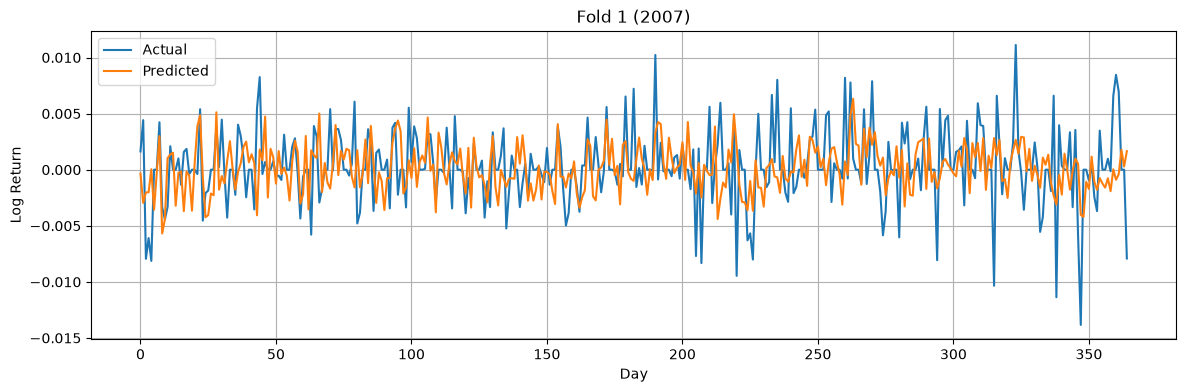

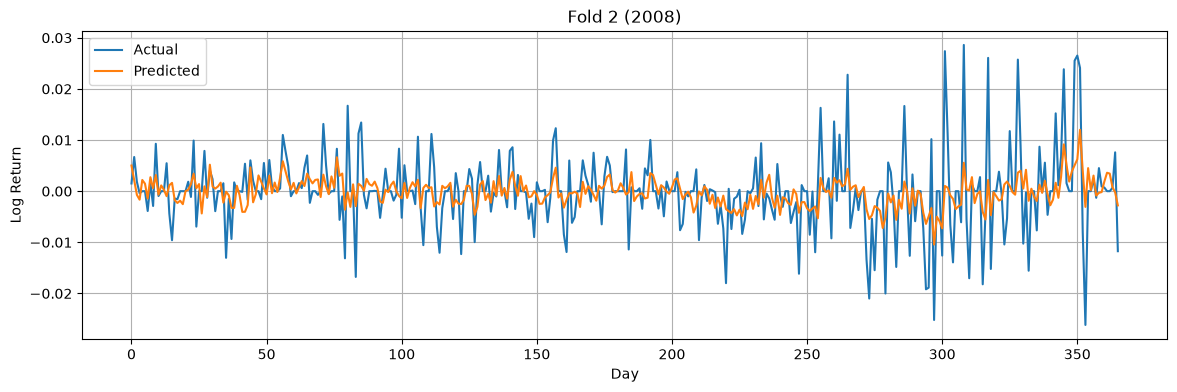

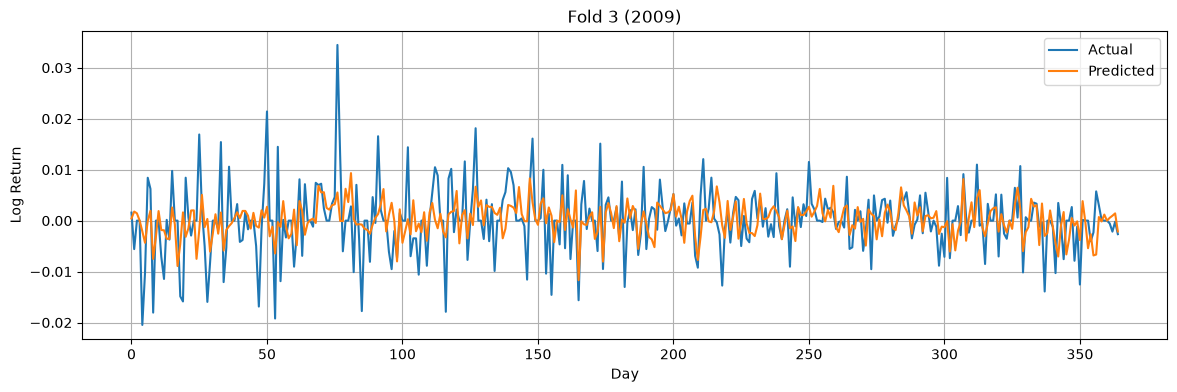

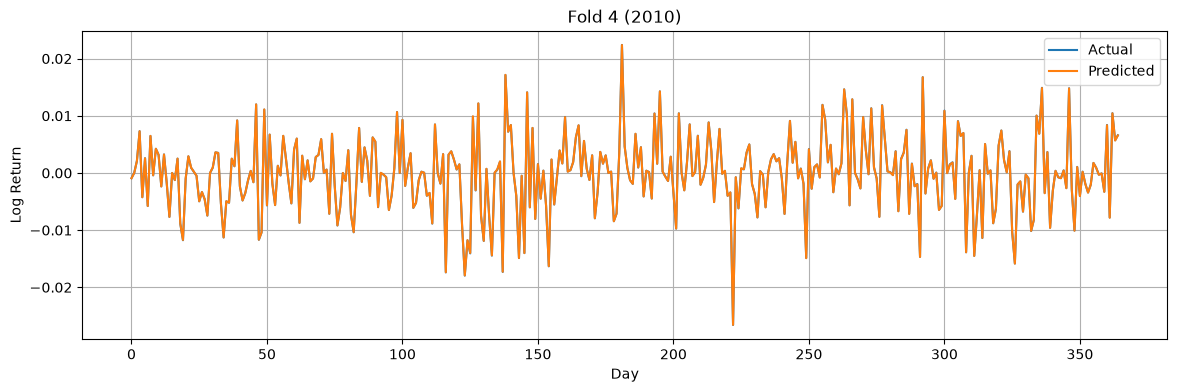

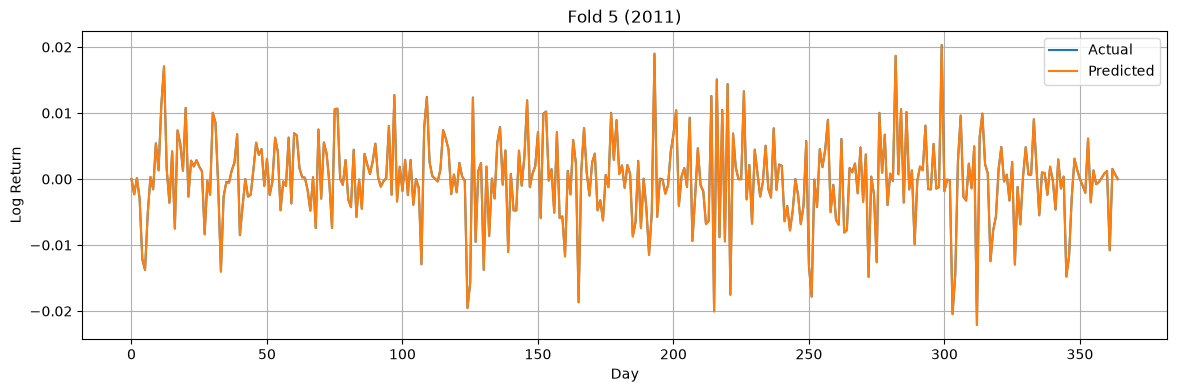

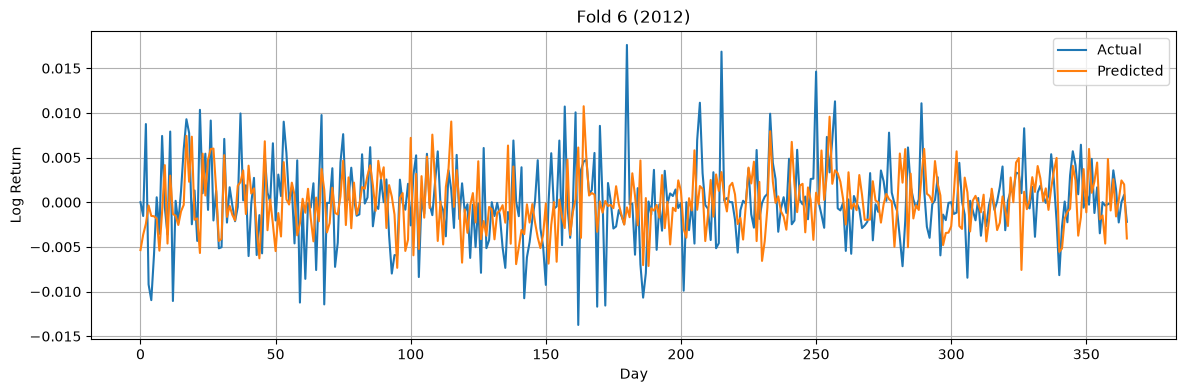

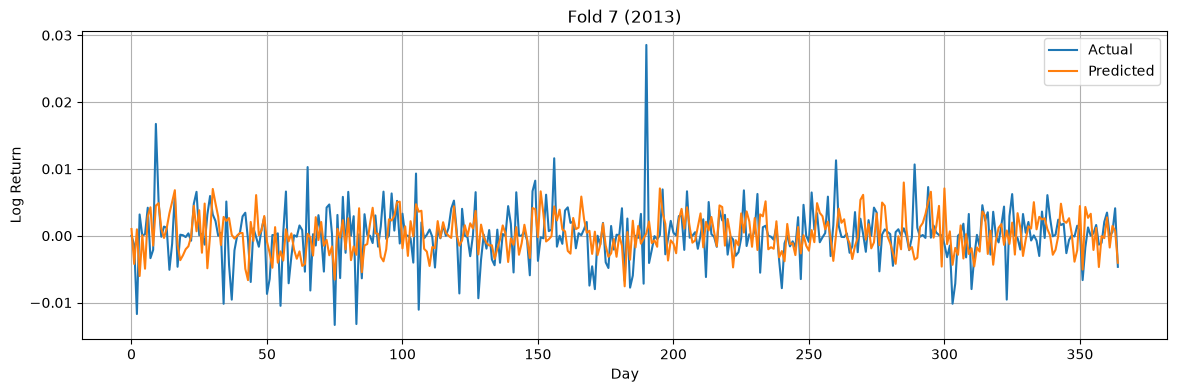

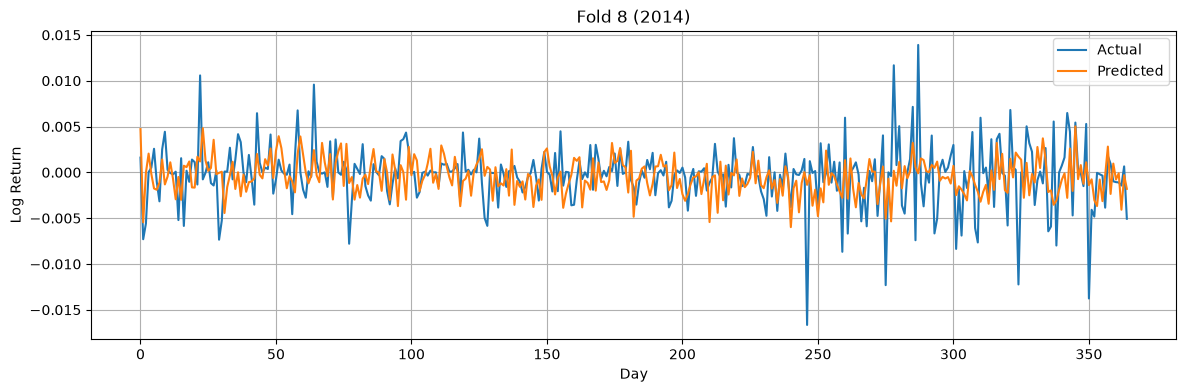

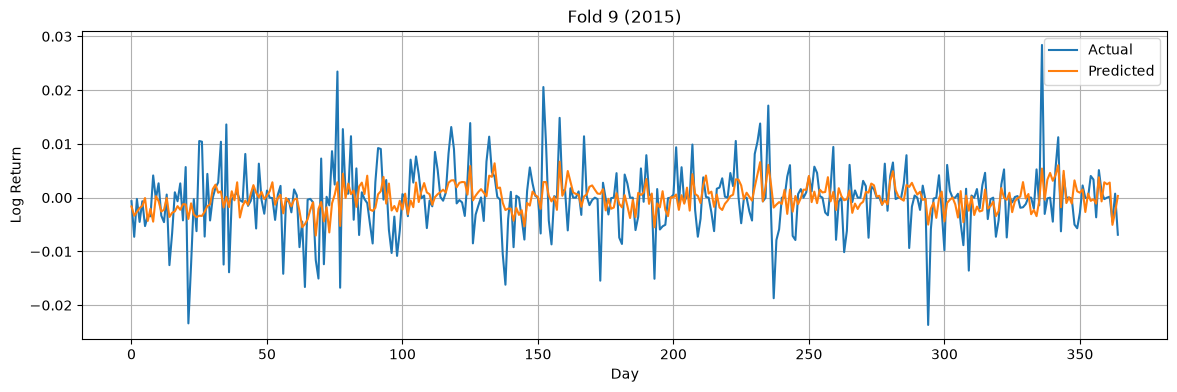

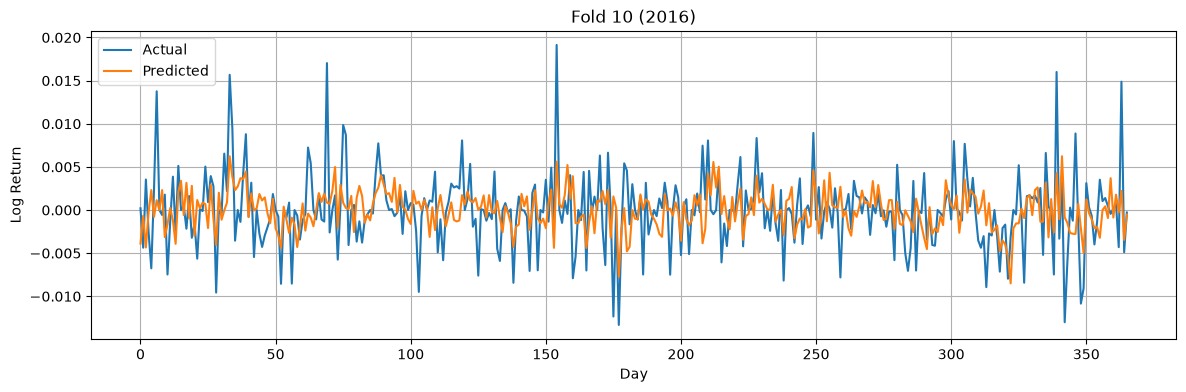

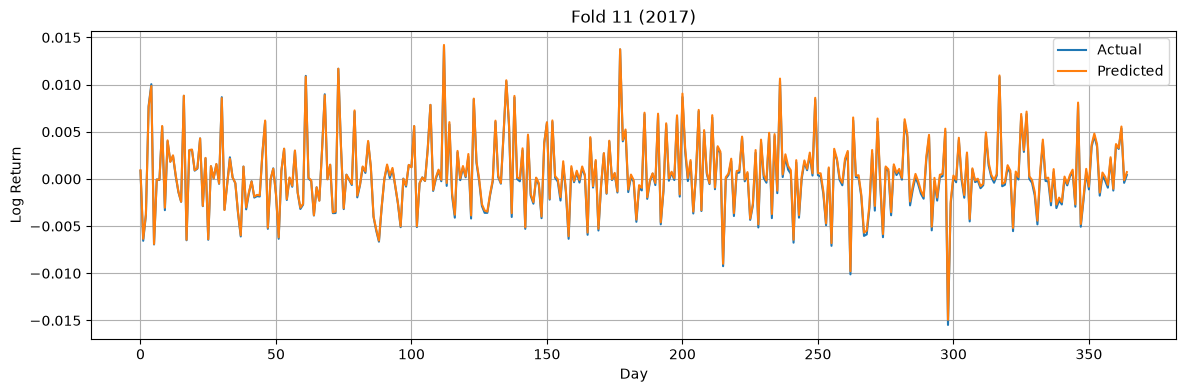

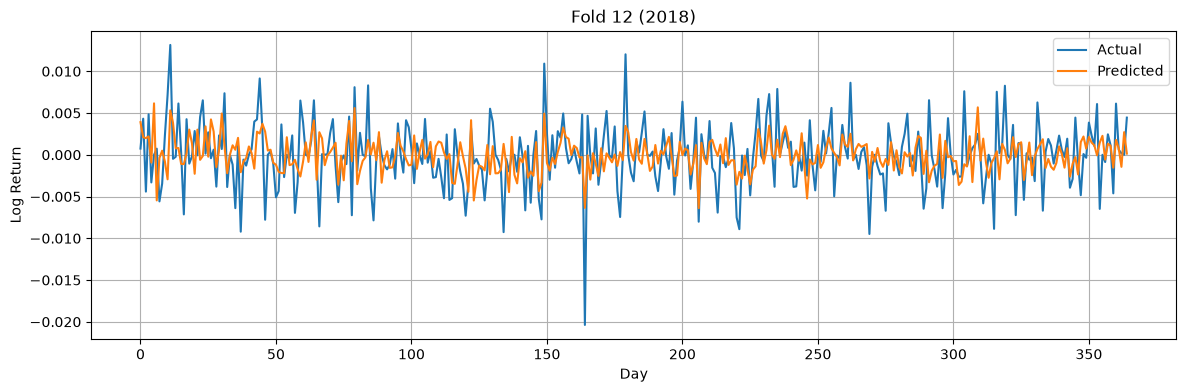

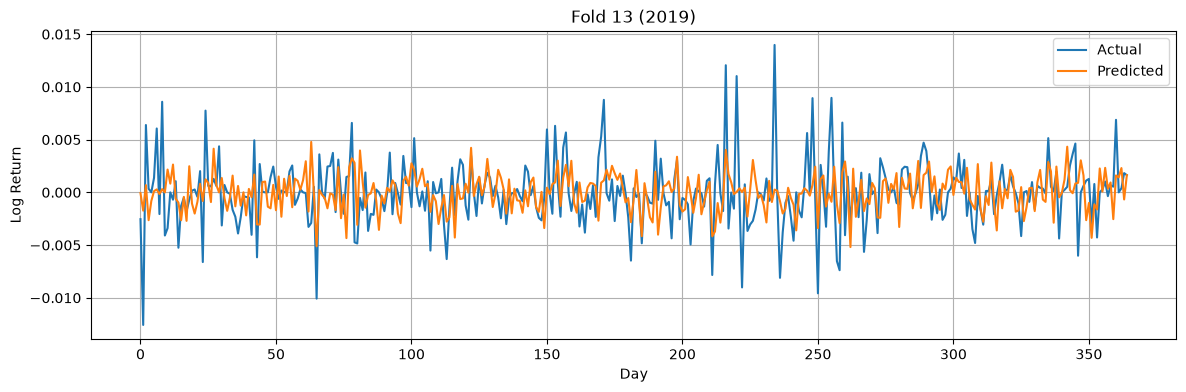

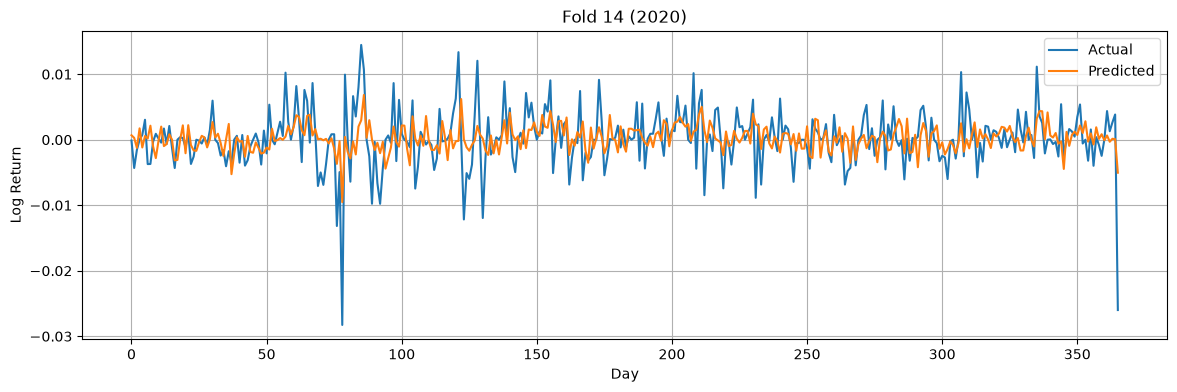

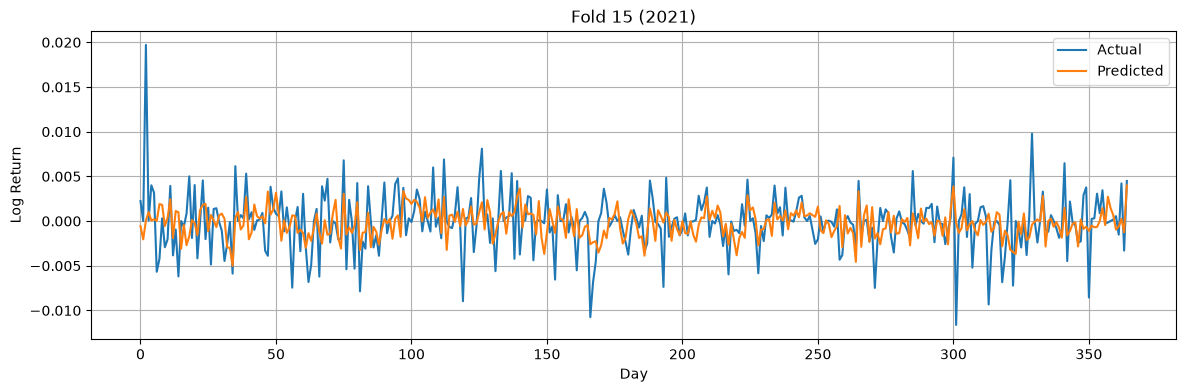

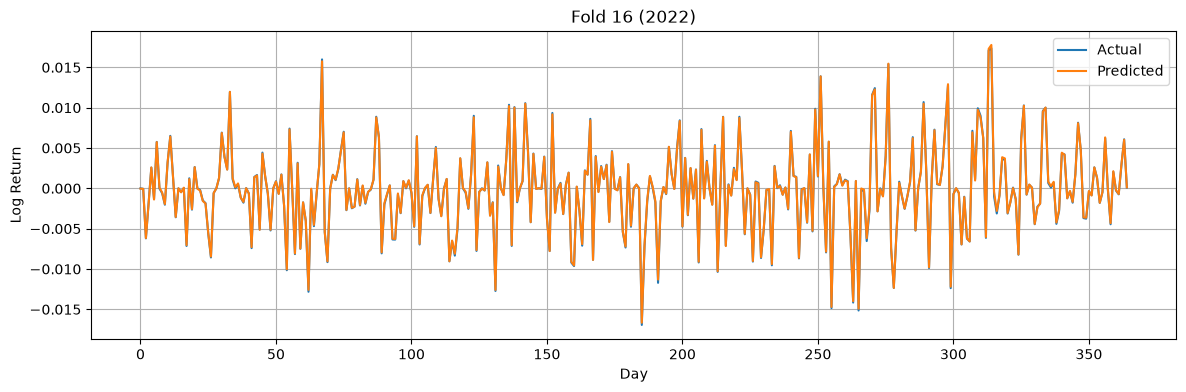

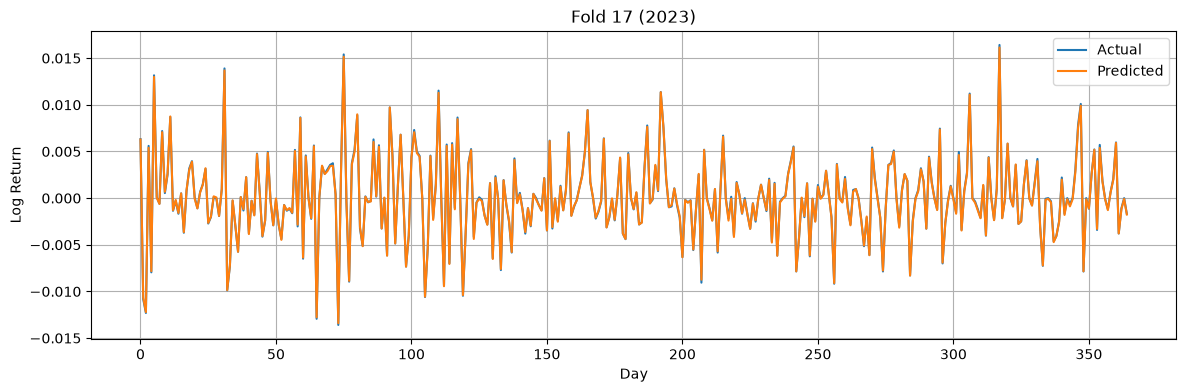

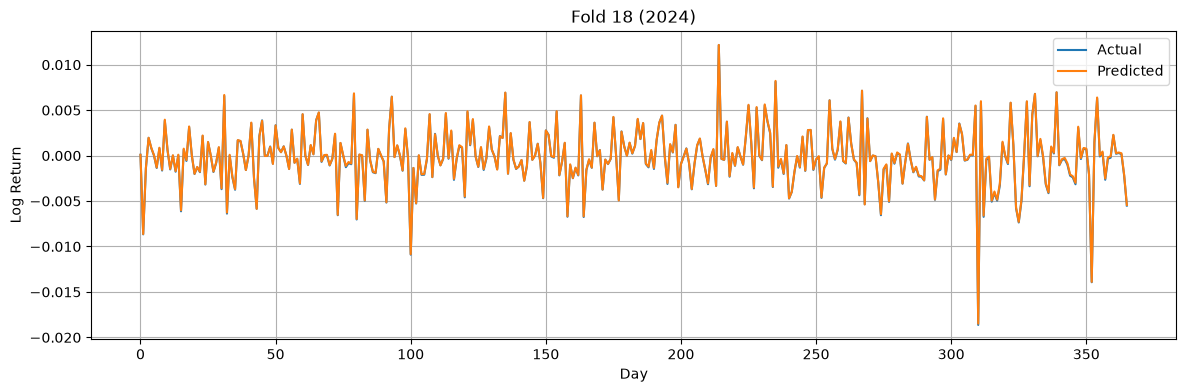

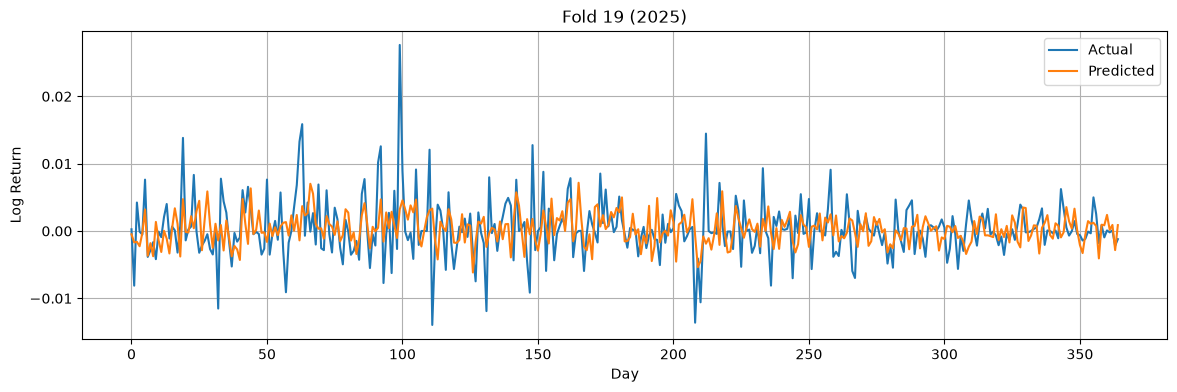

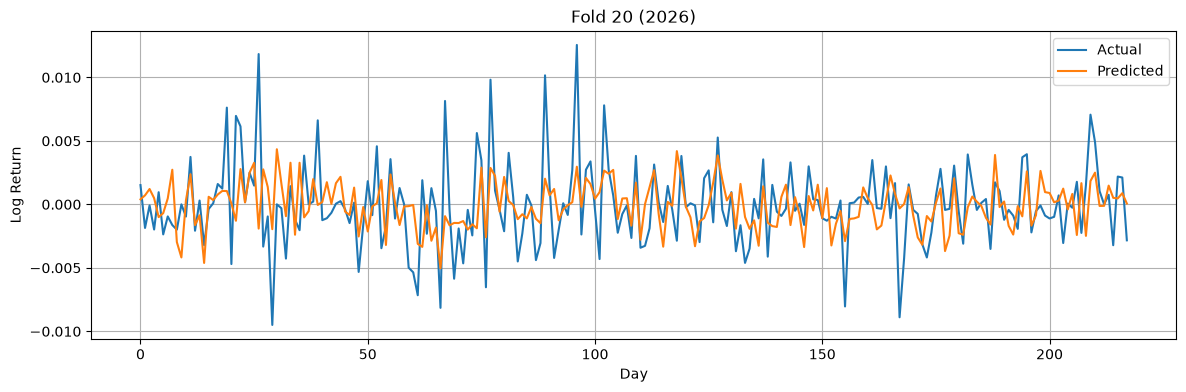

In [15]:
for i, pred in enumerate(predictions):

    plt.figure(figsize=(14,4))

    plt.plot(
        pred["y_true"],
        label="Actual"
    )

    plt.plot(
        pred["y_pred"],
        label="Predicted"
    )

    plt.title(
        f"Fold {i+1} ({results_df.loc[i,'Test Year']})"
    )

    plt.xlabel("Day")

    plt.ylabel("Log Return")

    plt.legend()

    plt.grid()

    plt.show()